# Text-to-SQL Agent: Ablation Study & Performance Analysis

## 1. Context & Objective
This notebook presents the rigorous evaluation of an autonomous Text-to-SQL agent querying a complex relational database (Olist Brazilian E-commerce dataset). The objective of this ablation study is to measure precisely how different architectural "modules" impact the LLM's ability to generate accurate, valid, and computationally efficient SQL queries.

## 2. Experimental Design
The evaluation was conducted in two distinct phases to separate the impact of architectural engineering from raw model capabilities:

**Phase 1: The Ablation Study (Architecture)**
We tested a strict matrix of $2^3 = 8$ configurations using `gpt-4o-mini` as the baseline model. We toggled three advanced agentic features ON and OFF to isolate their individual and combined impacts:
* **Few-Shot Prompting (FS):** Injecting three domain-specific examples (User Question + Correct SQL) into the prompt to guide syntax via In-Context Learning.
* **Self-Correction (SC):** An autonomous feedback loop. If the SQL triggers an SQLite error, the exact error trace is fed back to the LLM to rewrite its code (capped at 3 retries).
* **Chain-of-Thought Planner (CoT):** A preliminary reasoning node. The LLM is forced to output a strategic execution plan (identifying tables, `JOIN`s, and math logic) before writing any code.

**Phase 2: Generational Model Comparison (Scale)**
After identifying the optimal and heaviest configurations from Phase 1, we extended the benchmark across different LLM generations to evaluate the cost/performance trade-off:
* **gpt-3.5-turbo:** To establish a legacy baseline.
* **gpt-4o-mini:** The highly optimized, cost-efficient small model.
* **gpt-4o:** The frontier "heavyweight" model to establish the absolute performance ceiling.

## 3. Evaluation Metrics (Dependent Variables)
To avoid the limitations of traditional binary evaluation, we track four distinct metrics:
* **Strict Accuracy (%):** A strict row-matching metric. The agent's SQL execution output must perfectly match the output of a human-written "Gold SQL" baseline.
* **Semantic Accuracy (%):** Evaluated via an **LLM-as-a-Judge** framework using an absolute `gpt-4o` baseline. It scores the logic on a 0-3 scale, rewarding semantically correct answers even if the column sorting differs or if the agent made a valid business assumption.
* **Valid SQL Rate (%):** The percentage of queries that successfully execute without SQLite errors. It also counts correctly rejected out-of-scope questions.
* **Latency (Avg Time/Q):** The average execution time per question in seconds, critical for assessing the production cost of the agent.

## 4. Benchmark Dataset Categories
The evaluation runs against a custom dataset of 60 questions divided into four difficulties:
* **Simple:** Basic queries requiring 1 or 2 tables with standard `WHERE` filters and basic aggregations.
* **Complex:** Advanced queries requiring 3 or more `JOIN`s, subqueries, or complex date manipulations.
* **Ambiguous:** Vague business questions (e.g., *"Who are our best customers?"*) where no absolute "Gold SQL" exists. This tests the agent's ability to make logical, defensible data assumptions.
* **Out of Scope:** Questions entirely unrelated to the database schema. The agent is evaluated on its ability to gracefully refuse rather than hallucinating invalid SQL.

---
*The following cells ingest the summary history (`runs_history.json`) and the detailed row-by-row logs to visualize the model's behavior.*

In [2]:
!pip install pandas matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 53.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 73.5 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 65.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 76.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 67.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]9/10 [seaborn]ib]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os

In [4]:
# Set academic plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [6]:
# 1. Load Summary Data
with open('eval/runs_history.json', 'r') as f:
    runs_data = json.load(f)
df_runs = pd.DataFrame(runs_data)

In [7]:
# Create a readable 'Config Name' for plots based on toggles
def get_config_name(row):
    if row['Few-Shot'] and row['Self-Correction'] and row['CoT Planner']: return "Full Power"
    if not row['Few-Shot'] and not row['Self-Correction'] and not row['CoT Planner']: return "Baseline (Zero-Shot)"
    
    active = []
    if row['Few-Shot']: active.append("FS")
    if row['Self-Correction']: active.append("SC")
    if row['CoT Planner']: active.append("CoT")
    return " + ".join(active) if active else "Baseline"

df_runs['Config'] = df_runs.apply(get_config_name, axis=1)

In [8]:
# 2. Load Detailed CSV Data
csv_files = glob.glob('eval/runs/*.csv')
all_csv_data = []

for file in csv_files:
    # Assuming filename starts with Run ID (e.g., 'dfcb35c3_results.csv')
    run_id = os.path.basename(file).split('_')[0]
    try:
        df_temp = pd.read_csv(file)
        df_temp['Run ID'] = run_id
        all_csv_data.append(df_temp)
    except Exception as e:
        print(f"Error loading {file}: {e}")

if all_csv_data:
    df_details = pd.concat(all_csv_data, ignore_index=True)
    # Merge summary info into detailed info for cross-analysis
    df_full = df_details.merge(df_runs[['Run ID', 'Model', 'Config']], on='Run ID', how='left')
    print(f"Successfully loaded {len(df_runs)} runs and {len(df_full)} detailed question logs.")
else:
    print("Warning: No CSV files found in eval/runs/")
    
df_runs.head()

Successfully loaded 11 runs and 660 detailed question logs.


,Run ID,Timestamp,Model,Few-Shot,Self-Correction,CoT Planner,Strict Accuracy (%),Semantic Accuracy (%),Valid SQL Rate (%),Self-Corrections,Avg Time/Q (s),Config
0,dfcb35c3,2026-03-15 08:27:59,gpt-4o-mini,True,True,True,63.3,80.0,88.3,0,6.49,Full Power
1,6da6383c,2026-03-15 08:43:15,gpt-4o-mini,False,True,True,61.7,78.9,91.7,2,6.87,SC + CoT
2,ca885c3f,2026-03-15 15:07:10,gpt-4o-mini,True,False,True,66.7,80.0,85.0,0,8.46,FS + CoT
3,8135ccd4,2026-03-15 15:13:20,gpt-4o-mini,True,True,False,70.0,80.0,86.7,0,4.37,FS + SC
4,523ed22a,2026-03-15 15:21:17,gpt-4o-mini,False,False,True,61.7,75.0,83.3,0,6.90,CoT


### 1. Ablation Study: Isolating Module Impact on `gpt-4o-mini`
**Observation:** We analyze how each architectural component contributes to the overall Semantic Accuracy. 
Surprisingly, the hypothesis that "more modules yield better results" is challenged. The Chain-of-Thought (CoT) Planner appears to introduce noise or over-complication for this specific schema, while In-Context Learning (Few-Shot) remains the strongest driver of accuracy.

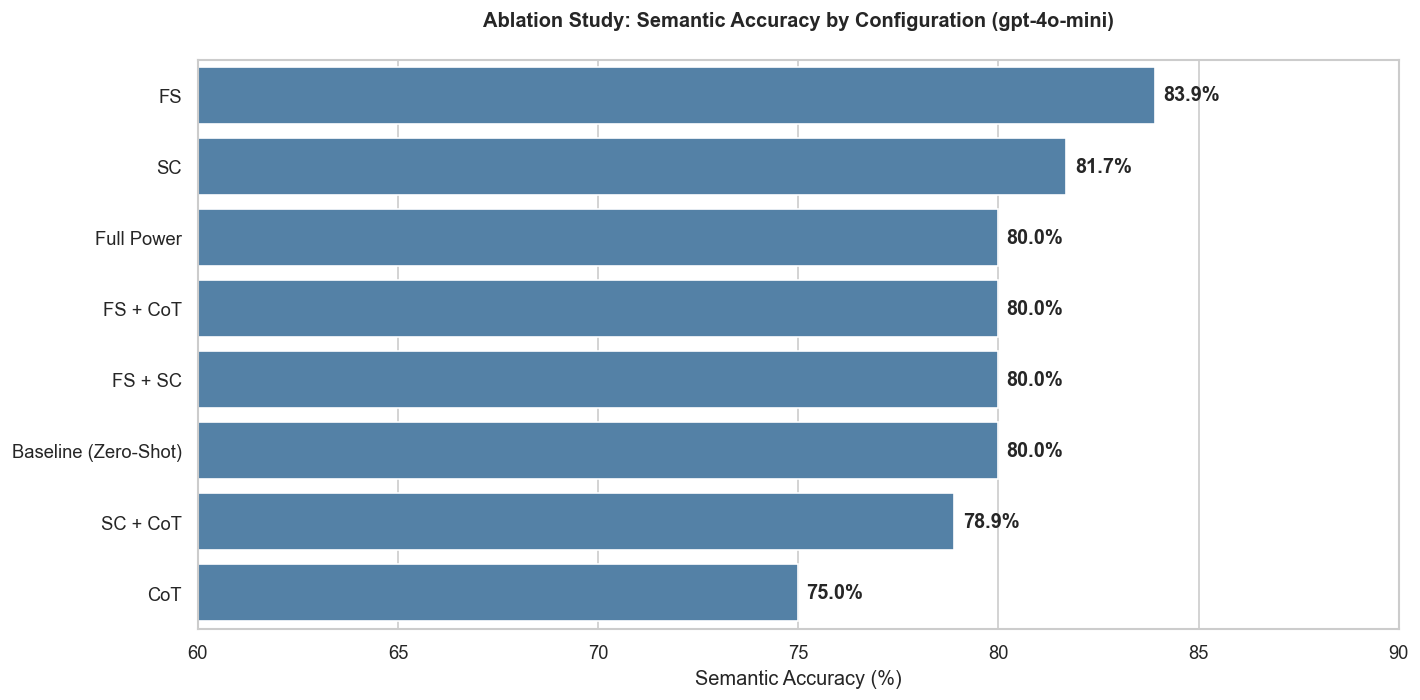

In [9]:
# Filter only gpt-4o-mini runs for the ablation study
df_mini = df_runs[df_runs['Model'] == 'gpt-4o-mini'].sort_values('Semantic Accuracy (%)', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_mini, x='Semantic Accuracy (%)', y='Config', color='steelblue')

# Add exact values on the bars
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.title('Ablation Study: Semantic Accuracy by Configuration (gpt-4o-mini)', pad=20, fontweight='bold')
plt.xlim(60, 90) # Zoom in to see differences clearly
plt.xlabel('Semantic Accuracy (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 2. The "Cost of Thinking": Latency vs. Accuracy
**Observation:** In real-world applications, latency is as critical as accuracy. This scatter plot demonstrates the trade-off. 
The optimal configuration resides in the top-left quadrant (High Accuracy, Low Latency). The CoT Planner pushes the model to the right (higher latency) without yielding a proportional increase in accuracy, confirming it is suboptimal for standard schema querying.

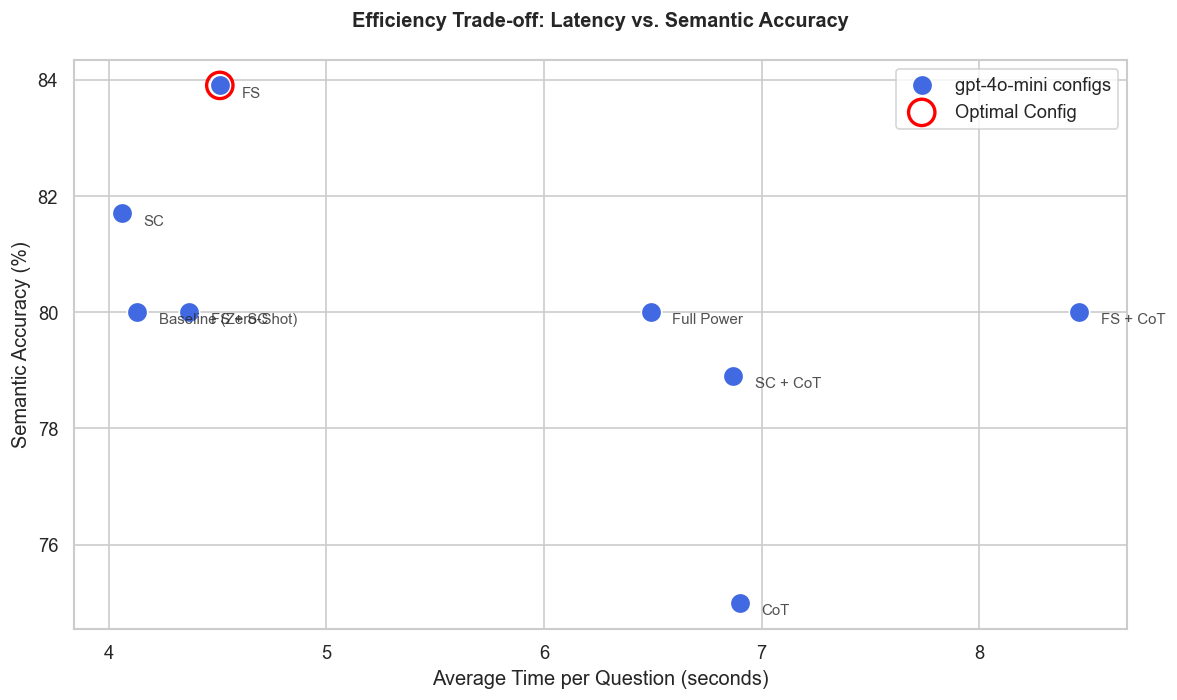

In [10]:
plt.figure(figsize=(10, 6))

# Plot gpt-4o-mini runs
sns.scatterplot(data=df_mini, x='Avg Time/Q (s)', y='Semantic Accuracy (%)', 
                s=150, color='royalblue', label='gpt-4o-mini configs')

# Highlight the optimal configuration (Highest Semantic Accuracy)
best_run = df_mini.loc[df_mini['Semantic Accuracy (%)'].idxmax()]
plt.scatter(best_run['Avg Time/Q (s)'], best_run['Semantic Accuracy (%)'], 
            s=250, edgecolor='red', facecolor='none', linewidth=2, label='Optimal Config')

# Add labels to points
for i, row in df_mini.iterrows():
    plt.text(row['Avg Time/Q (s)'] + 0.1, row['Semantic Accuracy (%)'] - 0.2, 
             row['Config'], fontsize=9, alpha=0.8)

plt.title('Efficiency Trade-off: Latency vs. Semantic Accuracy', pad=20, fontweight='bold')
plt.xlabel('Average Time per Question (seconds)')
plt.ylabel('Semantic Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

### 3. Model Comparison: Generational Leap and Ceiling Effects
**Observation:** We compare three generations of OpenAI models using the optimal configuration discovered during the ablation study (Few-Shot only) versus their "Full Power" configuration. 
The data proves that a highly optimized small model (`gpt-4o-mini`) vastly outperforms a standard legacy model (`gpt-3.5-turbo`), but still faces a reasoning ceiling compared to the frontier model (`gpt-4o`).

/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_12096/4032007434.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_per_model, x='Model', y='Semantic Accuracy (%)', ax=ax1, palette='viridis')
/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_12096/4032007434.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_per_model, x='Model', y='Avg Time/Q (s)', ax=ax2, palette='magma')


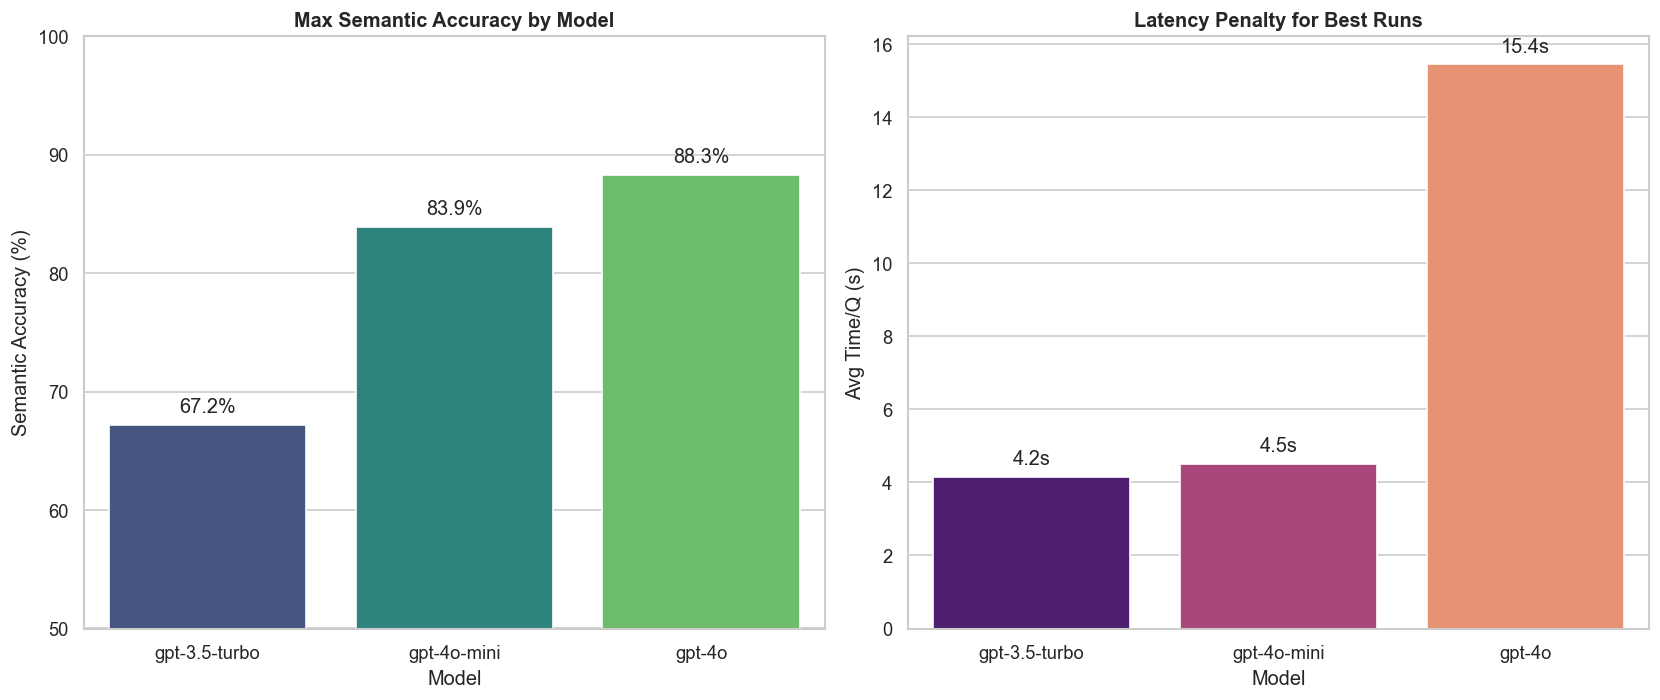

In [11]:
# Select key runs to compare (Modify the indices based on your exact Run IDs if needed)
# Here we compare gpt-3.5-turbo (Full), gpt-4o-mini (Optimal: FS only), and gpt-4o (Optimal/Full)
df_compare = df_runs[df_runs['Model'].isin(['gpt-3.5-turbo', 'gpt-4o', 'gpt-4o-mini'])]

# Group by Model to get the MAX score achieved by each model across all its runs
best_per_model = df_compare.loc[df_compare.groupby('Model')['Semantic Accuracy (%)'].idxmax()]
# Sort by accuracy
best_per_model = best_per_model.sort_values('Semantic Accuracy (%)', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Accuracy
sns.barplot(data=best_per_model, x='Model', y='Semantic Accuracy (%)', ax=ax1, palette='viridis')
ax1.set_title('Max Semantic Accuracy by Model', fontweight='bold')
ax1.set_ylim(50, 100)
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# Subplot 2: Latency for those best runs
sns.barplot(data=best_per_model, x='Model', y='Avg Time/Q (s)', ax=ax2, palette='magma')
ax2.set_title('Latency Penalty for Best Runs', fontweight='bold')
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}s", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### 4. Deep Dive: Performance by Query Difficulty
**Observation:** By merging the summary data with the detailed row-by-row execution logs, we can analyze where the LLM fails.
*Strict Accuracy* demands perfect row-matching, which naturally penalizes `ambiguous` queries (where no gold SQL exists). However, looking at *Semantic Accuracy* across categories reveals whether the agent successfully handles edge cases (like `out_of_scope` rejections) versus complex table joins.

/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_12096/3254366031.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=difficulty_stats, x='Difficulty', y='Semantically Correct', palette='cubehelix')


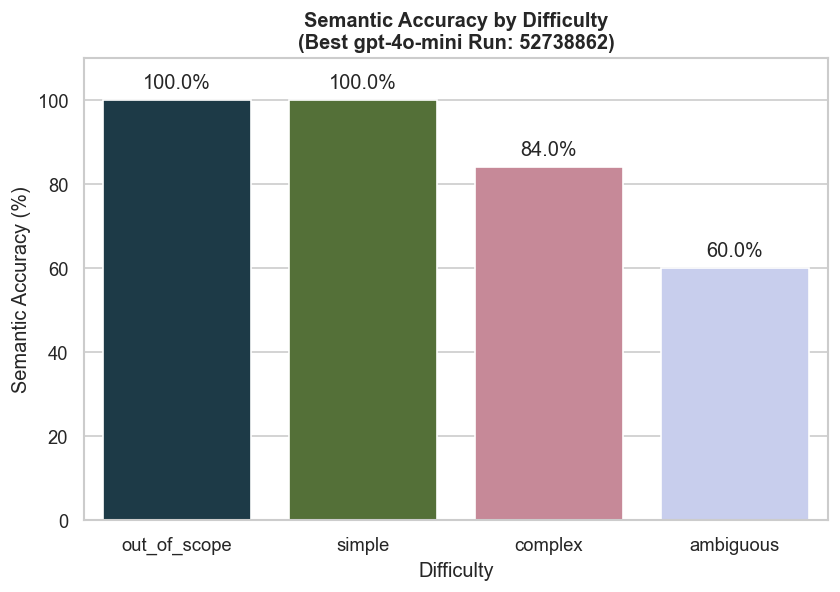

In [14]:
if 'df_full' in locals():
    # Let's focus on the BEST run of gpt-4o-mini to see where it struggles
    best_run_id = df_mini.iloc[0]['Run ID']
    df_best_details = df_full[df_full['Run ID'] == best_run_id].copy()
    
    # ✏️ CORRECTIF : Le nom exact de ta colonne
    col_score = 'Judge Score (/3)'
    
    if col_score in df_best_details.columns:
        # On extrait proprement le premier chiffre au cas où le score serait écrit "3/3"
        df_best_details['Numeric Score'] = df_best_details[col_score].astype(str).str.extract(r'(\d+)').astype(float)
        
        # On considère qu'un score >= 2 est "Sémantiquement Correct"
        df_best_details['Semantically Correct'] = df_best_details['Numeric Score'] >= 2
        
        difficulty_stats = df_best_details.groupby('Difficulty')['Semantically Correct'].mean() * 100
        difficulty_stats = difficulty_stats.reset_index().sort_values('Semantically Correct', ascending=False)
        
        plt.figure(figsize=(8, 5))
        ax = sns.barplot(data=difficulty_stats, x='Difficulty', y='Semantically Correct', palette='cubehelix')
        plt.title(f'Semantic Accuracy by Difficulty\n(Best gpt-4o-mini Run: {best_run_id})', fontweight='bold')
        plt.ylim(0, 110)
        plt.ylabel('Semantic Accuracy (%)')
        
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
            
        plt.show()
    else:
        print(f"❌ La colonne '{col_score}' est introuvable.")